In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/clean_loan_data.csv', parse_dates=['origination_date'])
sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


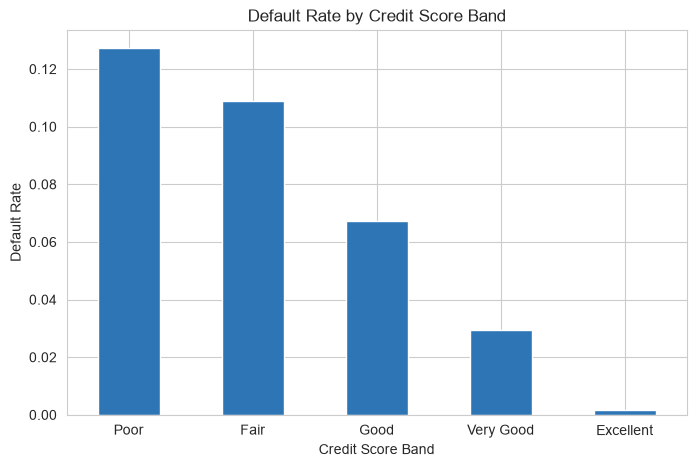

In [2]:
df['credit_score_band'] = pd.cut(
    df['orig_credit_score'],
    bins=[300, 580, 650, 700, 750, 850],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
)

default_by_band = df.groupby('credit_score_band')['default_flag'].mean()

plt.figure(figsize=(8,5))
default_by_band.plot(kind='bar', color='#2E75B6')
plt.title('Default Rate by Credit Score Band')
plt.ylabel('Default Rate')
plt.xlabel('Credit Score Band')
plt.xticks(rotation=0)
plt.show()

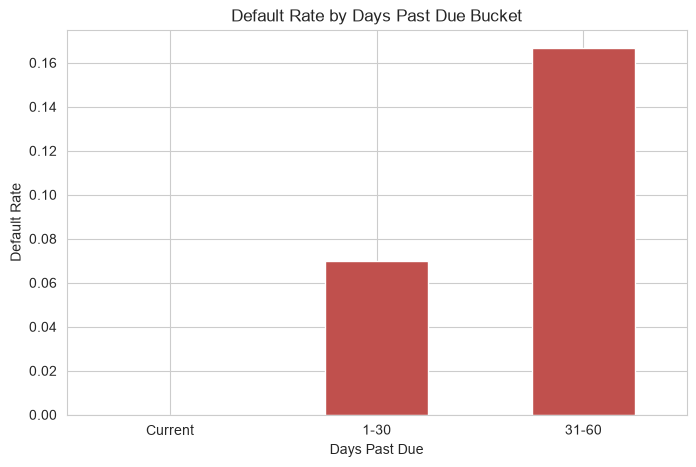

In [5]:
df['dpd_bucket'] = pd.cut(
    df['days_past_due'],
    bins=[-1, 0, 30, 60, 90, 180],
    labels=['Current', '1-30', '31-60', '61-90', '90+']
)

default_by_dpd = df.groupby('dpd_bucket')['default_flag'].mean()

plt.figure(figsize=(8,5))
default_by_dpd.plot(kind='bar', color='#C0504D')
plt.title('Default Rate by Days Past Due Bucket')
plt.ylabel('Default Rate')
plt.xlabel('Days Past Due')
plt.xticks(rotation=0)
plt.show()

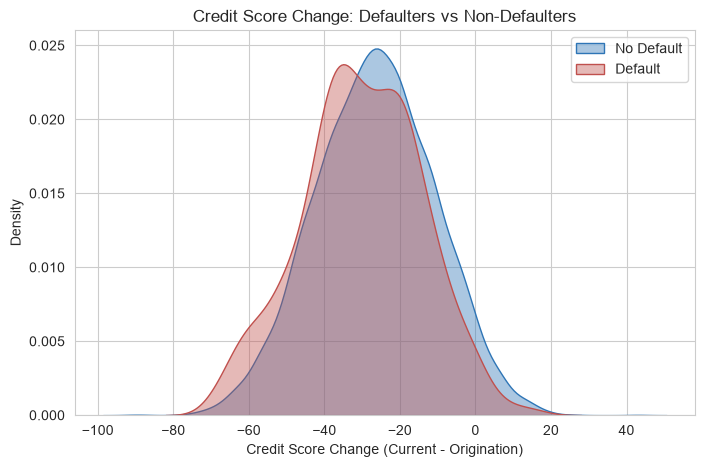

In [6]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['default_flag']==0], x='credit_score_change', label='No Default', fill=True, color='#2E75B6', alpha=0.4)
sns.kdeplot(data=df[df['default_flag']==1], x='credit_score_change', label='Default', fill=True, color='#C0504D', alpha=0.4)
plt.title('Credit Score Change: Defaulters vs Non-Defaulters')
plt.xlabel('Credit Score Change (Current - Origination)')
plt.legend()
plt.show()

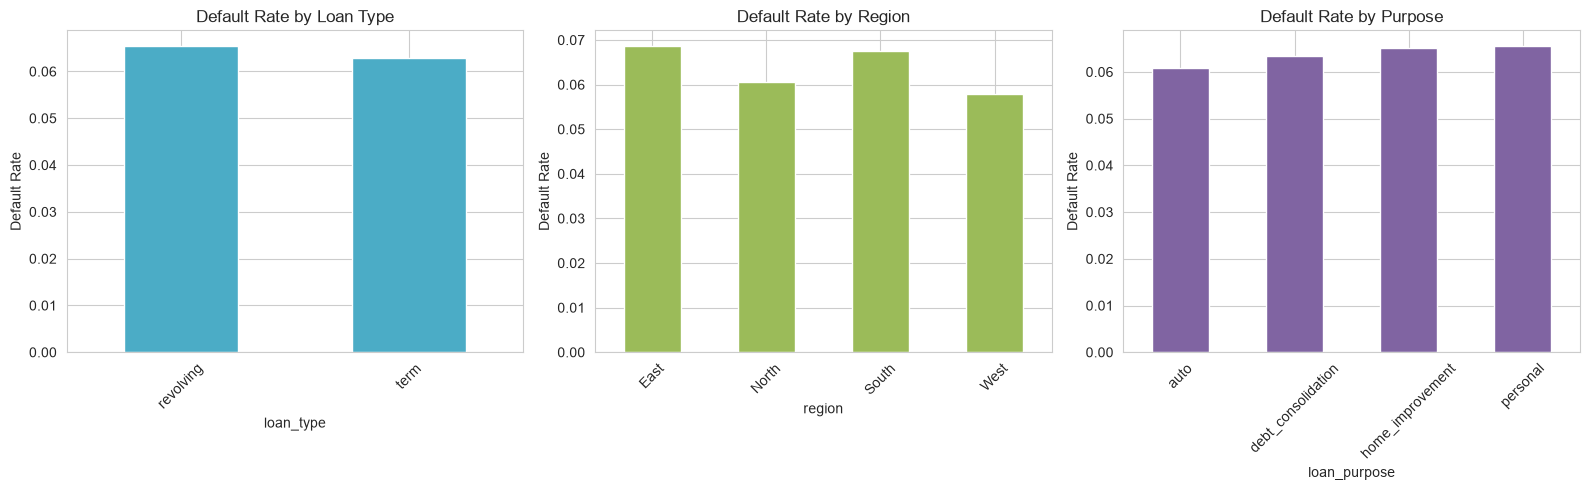

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

df.groupby('loan_type')['default_flag'].mean().plot(kind='bar', ax=axes[0], color='#4BACC6', title='Default Rate by Loan Type')
df.groupby('region')['default_flag'].mean().plot(kind='bar', ax=axes[1], color='#9BBB59', title='Default Rate by Region')
df.groupby('loan_purpose')['default_flag'].mean().plot(kind='bar', ax=axes[2], color='#8064A2', title='Default Rate by Purpose')

for ax in axes:
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Default rate increases clearly as credit score band worsens and as DPD increases, confirming these are the primary drivers of risk in this portfolio. Credit score change also separates defaulters from non-defaulters, supporting its use as a SICR indicator. Region and loan purpose show no strong pattern, consistent with how the synthetic data was generated.